In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score


C:\Users\zezoy\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
data=pd.read_csv('cirrhosis.csv')
data

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,415,1103,C,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,416,1055,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,417,691,C,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


In [3]:
# Check for null values
null_counts = data.isnull().sum()
print("Null Values:\n", null_counts)

# Check for duplicates
duplicates = data.duplicated()
print("Number of duplicate rows:", duplicates.sum())

# drop dupilcates 
data = data.drop_duplicates()

duplicatess = data.duplicated()
print("Number of duplicate rows:", duplicatess.sum())

Null Values:
 ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64
Number of duplicate rows: 0
Number of duplicate rows: 0


In [4]:
data = data.dropna()
data.isnull().sum()

ID               0
N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64

In [9]:
# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Encode the 'Color' column and create a new 'Color_Label' column
data['Drug'] = label_encoder.fit_transform(data['Drug'])
data['Sex'] = label_encoder.fit_transform(data['Sex'])
data['Ascites'] = label_encoder.fit_transform(data['Ascites'])
data['Hepatomegaly'] = label_encoder.fit_transform(data['Hepatomegaly'])
data['Spiders'] = label_encoder.fit_transform(data['Spiders'])
data['Edema'] = label_encoder.fit_transform(data['Edema'])
data['Status'] = label_encoder.fit_transform(data['Status'])

print(data)

      ID  N_Days  Status  Drug    Age  Sex  Ascites  Hepatomegaly  Spiders  \
0      1     400       2     0  21464    0        1             1        1   
1      2    4500       0     0  20617    0        0             1        1   
2      3    1012       2     0  25594    1        0             0        0   
3      4    1925       2     0  19994    0        0             1        1   
4      5    1504       1     1  13918    0        0             1        1   
..   ...     ...     ...   ...    ...  ...      ...           ...      ...   
307  308    1153       0     0  22347    0        0             1        0   
308  309     994       0     1  21294    0        0             0        0   
309  310     939       0     0  22767    0        0             0        0   
310  311     839       0     0  13879    0        0             0        0   
311  312     788       0     1  12109    0        0             0        1   

     Edema  ...  Cholesterol  Albumin  Copper  Alk_Phos    SGOT

In [11]:
print(data.describe())

               ID       N_Days      Status        Drug           Age  \
count  276.000000   276.000000  276.000000  276.000000    276.000000   
mean   158.615942  1979.166667    0.869565    0.507246  18189.326087   
std     91.662926  1112.380295    0.959743    0.500856   3843.555619   
min      1.000000    41.000000    0.000000    0.000000   9598.000000   
25%     79.750000  1185.750000    0.000000    0.000000  15162.500000   
50%    157.500000  1788.000000    0.000000    1.000000  18156.500000   
75%    240.250000  2689.750000    2.000000    1.000000  20667.500000   
max    312.000000  4556.000000    2.000000    1.000000  28650.000000   

              Sex     Ascites  Hepatomegaly     Spiders       Edema  \
count  276.000000  276.000000    276.000000  276.000000  276.000000   
mean     0.123188    0.068841      0.514493    0.289855    0.213768   
std      0.329250    0.253643      0.500698    0.454519    0.540665   
min      0.000000    0.000000      0.000000    0.000000    0.000000

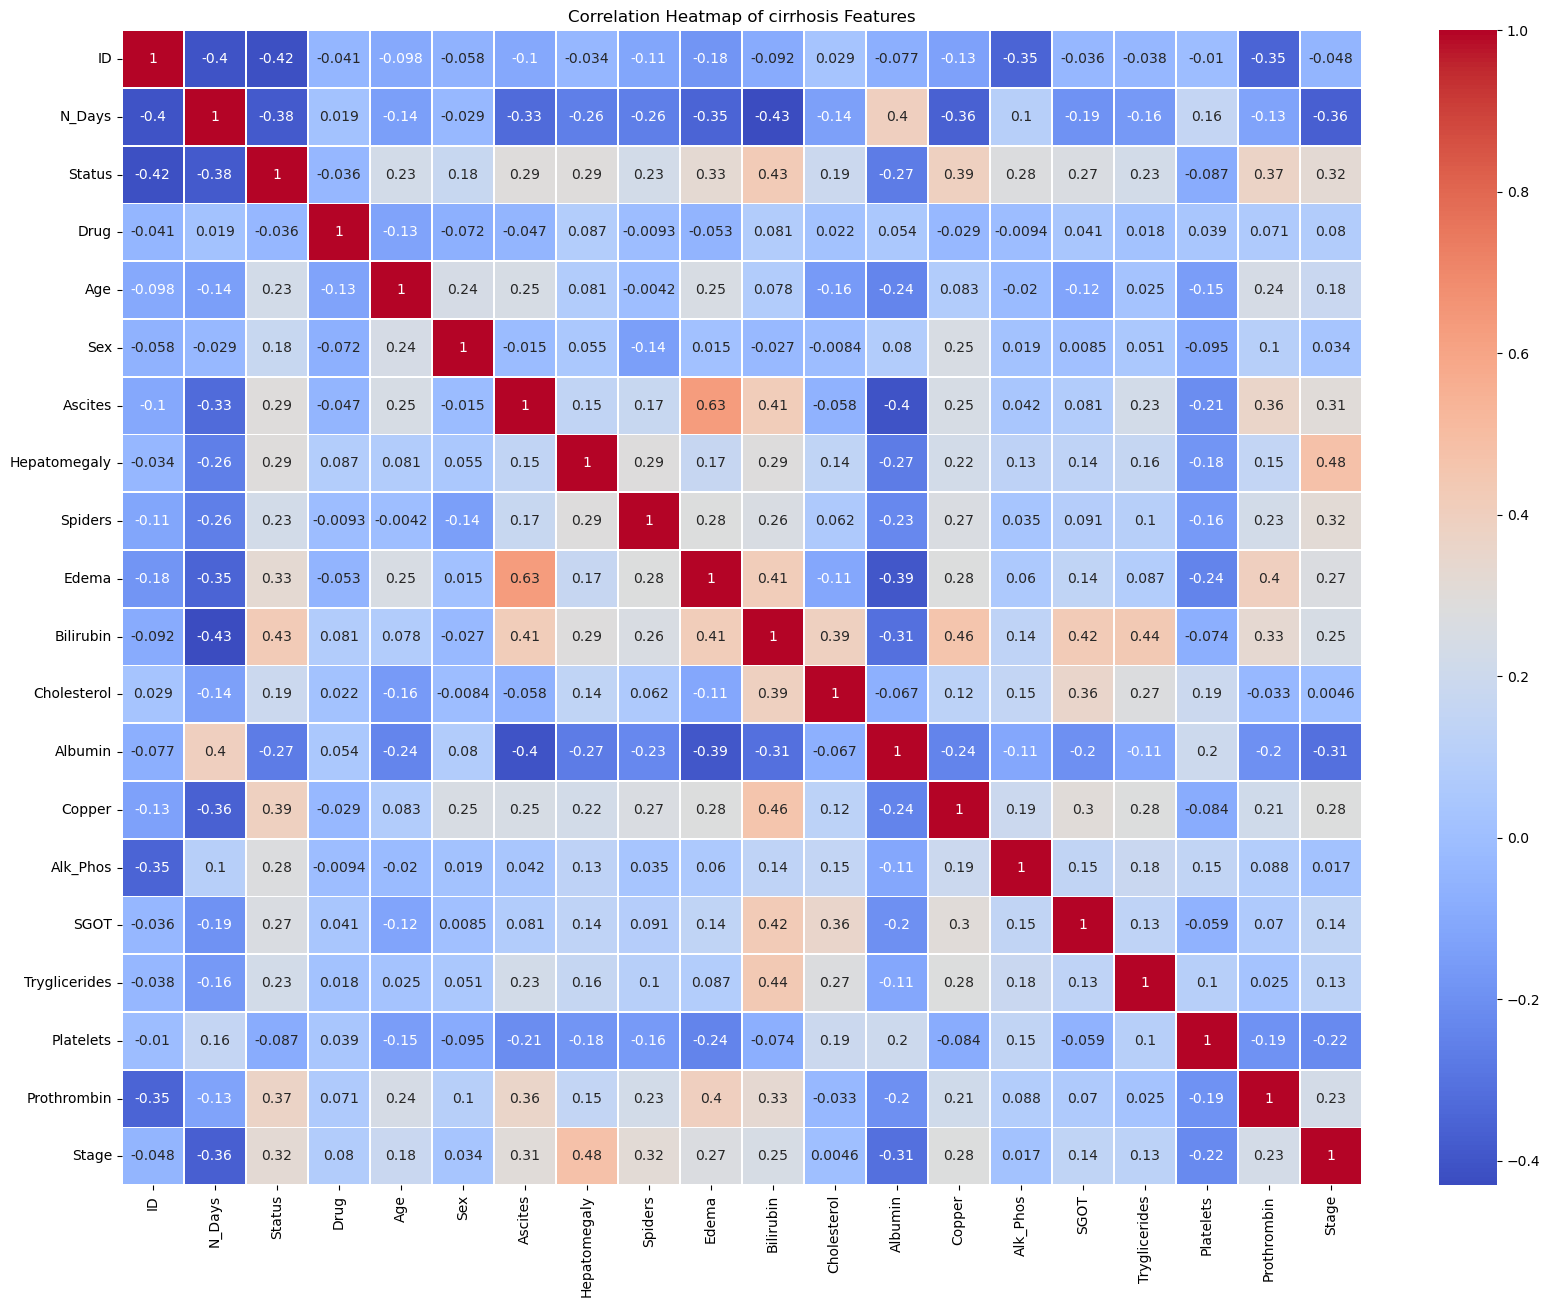

In [12]:
correlation_matrix = data.corr()
# Create a heatmap of correlations
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of cirrhosis Features')
plt.show()

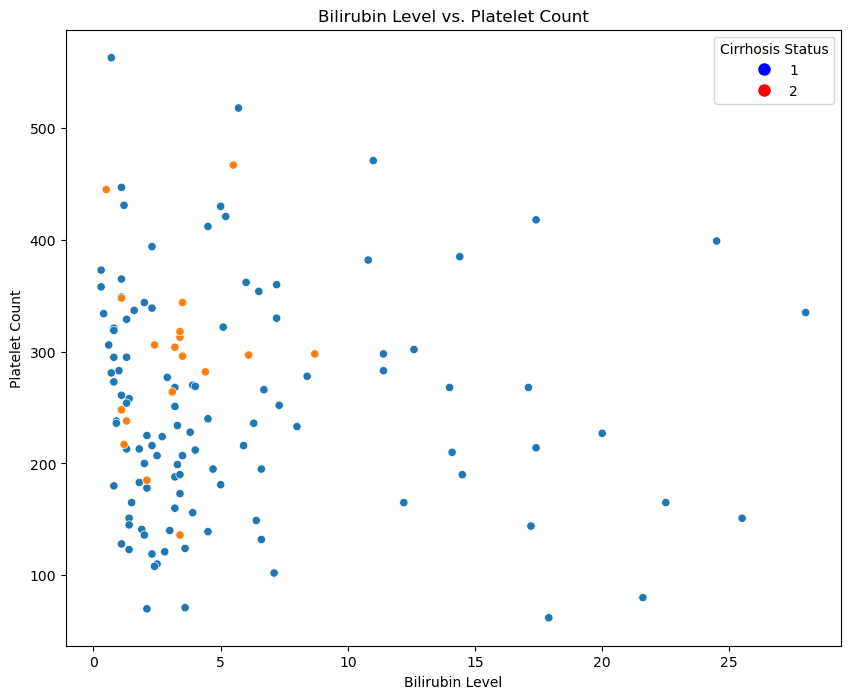

In [14]:
# Define the colors you want to use for each status
colors = {1: 'blue', 2: 'red'}

# Map the numerical values to color names
data['Status_Color'] = data['Status'].map(colors)

plt.figure(figsize=(10, 8))
sns.scatterplot(data=data, x='Bilirubin', y='Platelets', hue='Status_Color')
plt.xlabel('Bilirubin Level')
plt.ylabel('Platelet Count')
plt.title('Bilirubin Level vs. Platelet Count')

# Customize the legend
legend = plt.legend(title='Cirrhosis Status', handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors.values()], labels=colors.keys())

plt.show()


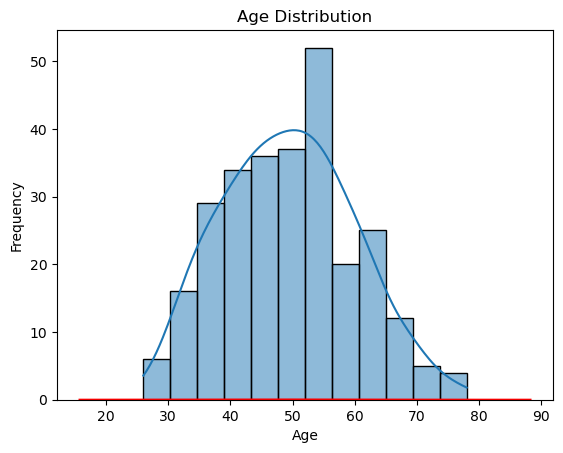

In [15]:
# Change the colors
bar_color = 'blue'  # Change this to the color you want for the bars
kde_color = 'red'   # Change this to the color you want for the KDE curve
years = data.Age // 365
sns.histplot(data=data, x=years, kde=True, palette=bar_color)
sns.kdeplot(data=data, x=years, color=kde_color)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


In [16]:
output_file = "cirrhosis1.csv"

# Save the DataFrame to a new CSV file
data.to_csv(output_file, index=False)

In [17]:
data=pd.read_csv('cirrhosis1.csv')
print(data)

      ID  N_Days  Status  Drug    Age  Sex  Ascites  Hepatomegaly  Spiders  \
0      1     400       2     0  21464    0        1             1        1   
1      2    4500       0     0  20617    0        0             1        1   
2      3    1012       2     0  25594    1        0             0        0   
3      4    1925       2     0  19994    0        0             1        1   
4      5    1504       1     1  13918    0        0             1        1   
..   ...     ...     ...   ...    ...  ...      ...           ...      ...   
271  308    1153       0     0  22347    0        0             1        0   
272  309     994       0     1  21294    0        0             0        0   
273  310     939       0     0  22767    0        0             0        0   
274  311     839       0     0  13879    0        0             0        0   
275  312     788       0     1  12109    0        0             0        1   

     Edema  ...  Cholesterol  Albumin  Copper  Alk_Phos    SGOT

# training the data

In [18]:
# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Encode the 'Color' column and create a new 'Color_Label' column
data['Status_Color'] = label_encoder.fit_transform(data['Status_Color'])

print(data)


      ID  N_Days  Status  Drug    Age  Sex  Ascites  Hepatomegaly  Spiders  \
0      1     400       2     0  21464    0        1             1        1   
1      2    4500       0     0  20617    0        0             1        1   
2      3    1012       2     0  25594    1        0             0        0   
3      4    1925       2     0  19994    0        0             1        1   
4      5    1504       1     1  13918    0        0             1        1   
..   ...     ...     ...   ...    ...  ...      ...           ...      ...   
271  308    1153       0     0  22347    0        0             1        0   
272  309     994       0     1  21294    0        0             0        0   
273  310     939       0     0  22767    0        0             0        0   
274  311     839       0     0  13879    0        0             0        0   
275  312     788       0     1  12109    0        0             0        1   

     Edema  ...  Cholesterol  Albumin  Copper  Alk_Phos    SGOT

In [19]:
X = data.iloc[:, data.columns != 'Status'].values
y = data.iloc[:, 2].values
print("print x",X)
print("print y",y)

print x [[1.000e+00 4.000e+02 0.000e+00 ... 1.220e+01 4.000e+00 1.000e+00]
 [2.000e+00 4.500e+03 0.000e+00 ... 1.060e+01 3.000e+00 2.000e+00]
 [3.000e+00 1.012e+03 0.000e+00 ... 1.200e+01 4.000e+00 1.000e+00]
 ...
 [3.100e+02 9.390e+02 0.000e+00 ... 1.020e+01 2.000e+00 2.000e+00]
 [3.110e+02 8.390e+02 0.000e+00 ... 1.050e+01 2.000e+00 2.000e+00]
 [3.120e+02 7.880e+02 1.000e+00 ... 1.080e+01 2.000e+00 2.000e+00]]
print y [2 0 2 2 1 0 2 2 2 2 2 0 2 0 2 2 0 2 0 2 2 2 0 2 2 2 0 2 2 0 2 0 2 0 2 2 2
 0 2 2 0 0 2 2 2 2 2 2 2 2 0 0 2 2 2 0 2 2 0 2 0 0 0 2 2 2 2 2 0 2 2 2 0 0
 2 2 2 0 2 2 2 2 0 2 2 0 0 2 0 0 2 2 1 0 2 0 2 1 2 2 2 0 0 2 2 2 1 2 0 0 1
 0 2 2 0 2 0 0 0 0 2 0 0 0 2 2 2 0 0 2 2 0 2 0 2 0 2 0 1 2 0 0 2 2 2 0 2 2
 0 0 0 0 0 0 0 0 1 2 0 2 2 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 2 2
 2 0 2 0 2 2 0 0 0 2 0 2 0 2 0 0 0 0 0 0 2 0 1 0 2 2 0 1 1 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 1 1 0 2 2 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 1 2 0 1 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
print("X_train:", X_train)
print("X_test",X_test)
print("y_train",y_train)
print("y_test",y_test)

X_train: [[4.400e+01 3.428e+03 1.000e+00 ... 1.170e+01 3.000e+00 1.000e+00]
 [2.950e+02 8.770e+02 0.000e+00 ... 1.030e+01 3.000e+00 0.000e+00]
 [1.300e+02 1.413e+03 1.000e+00 ... 1.150e+01 3.000e+00 1.000e+00]
 ...
 [1.200e+02 2.033e+03 0.000e+00 ... 1.060e+01 3.000e+00 0.000e+00]
 [3.070e+02 1.149e+03 1.000e+00 ... 1.050e+01 2.000e+00 2.000e+00]
 [1.160e+02 3.336e+03 0.000e+00 ... 9.900e+00 3.000e+00 2.000e+00]]
X_test [[3.300e+01 3.170e+03 1.000e+00 ... 1.200e+01 3.000e+00 1.000e+00]
 [1.420e+02 2.419e+03 1.000e+00 ... 9.900e+00 2.000e+00 1.000e+00]
 [2.290e+02 3.480e+02 0.000e+00 ... 1.140e+01 4.000e+00 1.000e+00]
 ...
 [6.500e+01 3.992e+03 0.000e+00 ... 1.000e+01 1.000e+00 2.000e+00]
 [2.190e+02 2.157e+03 1.000e+00 ... 9.600e+00 3.000e+00 2.000e+00]
 [2.840e+02 1.418e+03 1.000e+00 ... 9.500e+00 3.000e+00 2.000e+00]]
y_train [2 1 2 2 1 0 2 0 1 2 0 0 0 0 0 0 0 2 2 0 2 2 2 0 0 0 2 2 2 0 0 2 2 0 0 0 0
 0 0 0 0 2 2 0 2 2 0 0 2 2 2 2 0 0 0 0 0 2 0 0 0 2 0 0 0 2 2 0 2 0 2 2 2 0
 0 2 0 0 0

# Decision Tree

In [58]:
DecisionTree = DecisionTreeClassifier(min_samples_leaf=20, random_state=42)

DecisionTree.fit(X_train, y_train)

DecisionTreeClassifier(min_samples_leaf=20, random_state=42)

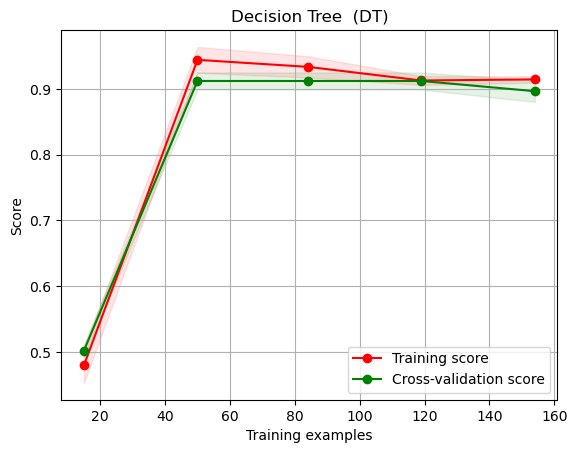

In [59]:
plot_learning_curve(DecisionTree, "Decision Tree  (DT)", X_train, y_train, cv=5)
plt.show()

# random forest classifier

In [72]:
RandomForest = RandomForestClassifier(min_samples_leaf=5, random_state=42)

RandomForest.fit(X_train, y_train)

RandomForestClassifier(min_samples_leaf=5, random_state=42)

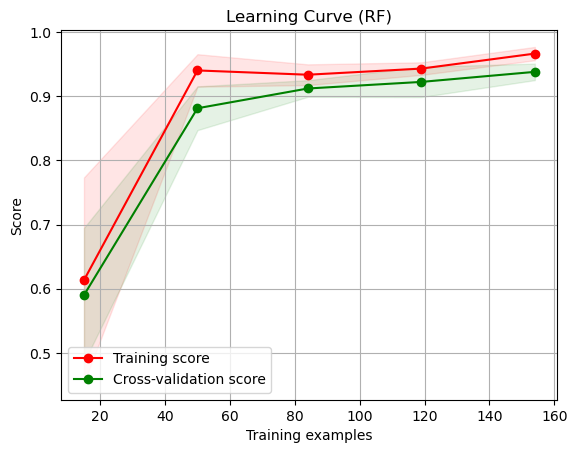

In [73]:
plot_learning_curve(RandomForest, "Learning Curve (RF)", X_train, y_train, cv=5)
plt.show()

# Support Vector Machine (SVM)

In [62]:
SVC = SVC(random_state = 42)
SVC.fit(X_train, y_train)

SVC(random_state=42)

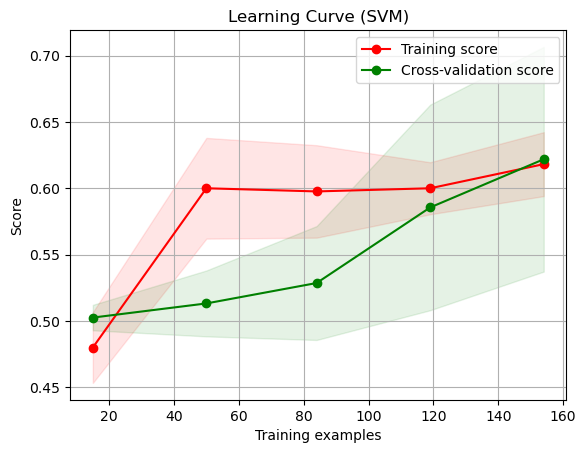

In [63]:
plot_learning_curve(SVC, "Learning Curve (SVM)", X_train, y_train, cv=5)
plt.show()

# measure and compare the Accuracy

In [74]:
y_pred_dt = DecisionTree.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

y_pred_rf = RandomForest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

y_pred_svm = SVC.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print(f"SVM Accuracy: {accuracy_svm:.2f}")


Decision Tree Accuracy: 0.96
Random Forest Accuracy: 0.99
SVM Accuracy: 0.72


In [75]:
confusion_matrix_dt = confusion_matrix(y_test, y_pred_dt)
confusion_matrix_rf = confusion_matrix(y_test, y_pred_rf)
confusion_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix (Decision Tree):")
print(confusion_matrix_dt)

print("Confusion Matrix (Random Forest):")
print(confusion_matrix_rf)

print("Confusion Matrix (SVM):")
print(confusion_matrix_svm)


Confusion Matrix (Logistic Regression):
[[50  0  0]
 [ 0  1  0]
 [ 0  3 29]]
Confusion Matrix (Random Forest):
[[50  0  0]
 [ 0  0  1]
 [ 0  0 32]]
Confusion Matrix (SVM):
[[47  0  3]
 [ 1  0  0]
 [19  0 13]]


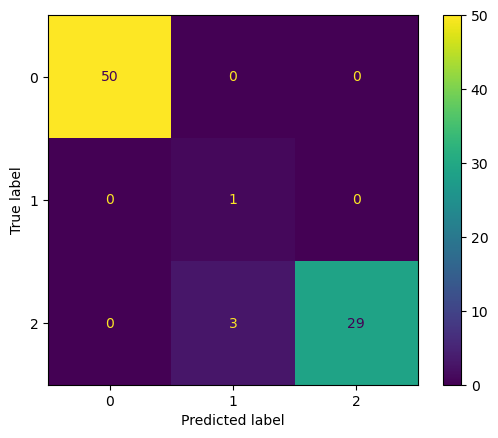

In [82]:
y_pred = DecisionTree.predict(X_test)
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
cm = confusion_matrix(y_test, y_pred, labels=tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=tree.classes_)
disp.plot()
plt.show()

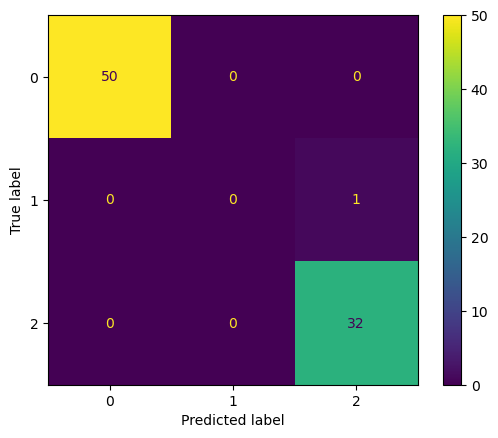

In [83]:
y_pred = RandomForest.predict(X_test)
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
cm = confusion_matrix(y_test, y_pred, labels=tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=tree.classes_)
disp.plot()
plt.show()

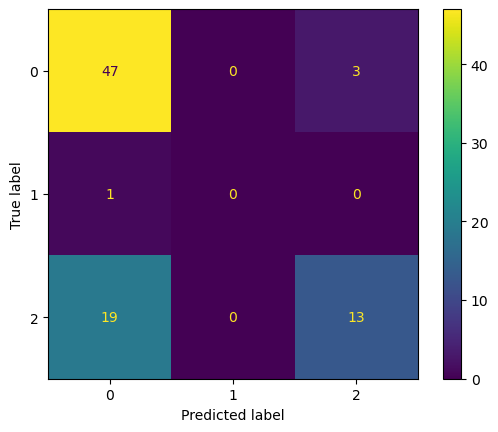

In [84]:
y_pred = SVC.predict(X_test)
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
cm = confusion_matrix(y_test, y_pred, labels=tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=tree.classes_)
disp.plot()
plt.show()